# 05 - Gözetimsiz Makine Öğrenmesi
## Uydu Telemetri Anomali Tespiti

Etiket kullanmadan anomali tespiti. Modeller sadece Normal verilerle eğitilir.

### Modeller:
1. Isolation Forest
2. One-Class SVM
3. K-Means Clustering
4. Local Outlier Factor
5. Autoencoder


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import json, warnings, joblib

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, roc_auc_score, roc_curve, auc
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.cluster import KMeans
from sklearn.neighbors import LocalOutlierFactor

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
print('Kütüphaneler yüklendi.')


Kütüphaneler yüklendi.


---
## Bölüm 0: Veri Hazırlama


In [2]:
# NB02'nin (ön işleme) kanonik RobustScaler'ini yeniden kullan — scaler burada YENİDEN
# FIT EDİLMEZ (leakage-free, tek ölçekleme kaynağı; NB02 ile tutarlı). Gözetimsiz protokol
# SMOTE kullanmadığından, T içinden non-SMOTE bir validation split kurulur.
ESA_18_FEATURES = [
    'mean', 'var', 'std', 'kurtosis', 'skew', 'n_peaks',
    'duration', 'len', 'gaps_squared', 'len_weighted',
    'var_div_duration', 'var_div_len',
    'smooth10_n_peaks', 'smooth20_n_peaks',
    'diff_peaks', 'diff2_peaks', 'diff_var', 'diff2_var',
]
scaler = joblib.load('../models/robust_scaler.joblib')   # NB02'de T üzerinde fit edildi
dataset = pd.read_csv('../data/raw/dataset.csv')
train_df = dataset[dataset['train'] == 1].copy()
test_df  = dataset[dataset['train'] == 0].copy()
X_train_full = train_df[ESA_18_FEATURES].fillna(0)
y_train_full = train_df['anomaly'].reset_index(drop=True)
X_test = test_df[ESA_18_FEATURES].fillna(0)
y_test = test_df['anomaly'].reset_index(drop=True)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full)

# Yalnız transform (fit YOK) — NB02'nin RobustScaler'ı
X_tr_s   = scaler.transform(X_tr)
X_val_s  = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)
X_normal_train = X_tr_s[(y_tr == 0).values]

print(f"NB02 RobustScaler ile ölçeklendi — Eğitim (yalnız Normal): {X_normal_train.shape}, "
      f"Val: {X_val_s.shape}, Test Ψ: {X_test_s.shape}")

def find_best_threshold(scores, y_true):
    best_f1, best_t = 0, np.percentile(scores, 90)
    for p in np.arange(40, 99.5, 0.5):
        t = np.percentile(scores, p)
        preds = (scores > t).astype(int)
        f = f1_score(y_true, preds, zero_division=0)
        if f > best_f1: best_f1, best_t = f, t
    return best_t, best_f1

NB02 RobustScaler ile ölçeklendi — Eğitim (yalnız Normal): (1081, 18), Val: (240, 18), Test Ψ: (529, 18)


---
## Bölüm 1: Isolation Forest


              precision    recall  f1-score   support

      Normal       0.83      0.82      0.83       416
     Anomali       0.38      0.39      0.38       113

    accuracy                           0.73       529
   macro avg       0.60      0.61      0.61       529
weighted avg       0.74      0.73      0.73       529

AUC: 0.6847


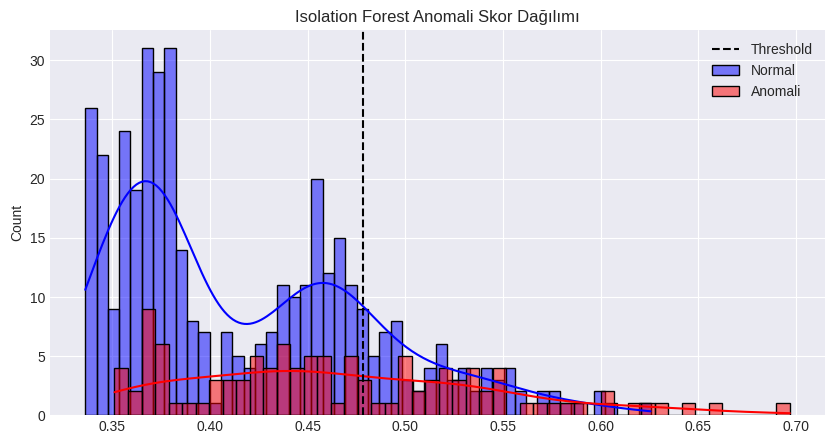

In [3]:
iso = IsolationForest(n_estimators=200, max_features=0.75, contamination=0.05, random_state=42, n_jobs=-1)
iso.fit(X_normal_train)

scores_val = -iso.score_samples(X_val_s)
iso_thresh, val_f1 = find_best_threshold(scores_val, y_val.values)
scores_test = -iso.score_samples(X_test_s)
y_pred = (scores_test > iso_thresh).astype(int)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomali']))
print(f"AUC: {roc_auc_score(y_test, scores_test):.4f}")

plt.figure(figsize=(10, 5))
sns.histplot(scores_test[y_test==0], color='blue', label='Normal', kde=True, bins=50)
sns.histplot(scores_test[y_test==1], color='red', label='Anomali', kde=True, bins=50)
plt.axvline(x=iso_thresh, color='black', linestyle='--', label='Threshold')
plt.title('Isolation Forest Anomali Skor Dağılımı'); plt.legend(); plt.show()


---
## Bölüm 2: One-Class SVM


In [4]:
ocsvm = OneClassSVM(kernel='rbf', gamma=0.1, nu=0.05)
ocsvm.fit(X_normal_train)
scores_val = -ocsvm.decision_function(X_val_s)
ocsvm_thresh, _ = find_best_threshold(scores_val, y_val.values)
scores_test = -ocsvm.decision_function(X_test_s)
y_pred = (scores_test > ocsvm_thresh).astype(int)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomali']))
print(f"AUC: {roc_auc_score(y_test, scores_test):.4f}")


              precision    recall  f1-score   support

      Normal       0.93      0.92      0.92       416
     Anomali       0.71      0.74      0.72       113

    accuracy                           0.88       529
   macro avg       0.82      0.83      0.82       529
weighted avg       0.88      0.88      0.88       529

AUC: 0.8202


---
## Bölüm 3: K-Means Clustering


In [5]:
km = KMeans(n_clusters=10, random_state=42, n_init='auto')
km.fit(X_normal_train)
scores_val = np.min(km.transform(X_val_s), axis=1)
km_thresh, _ = find_best_threshold(scores_val, y_val.values)
scores_test = np.min(km.transform(X_test_s), axis=1)
y_pred = (scores_test > km_thresh).astype(int)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomali']))
print(f"AUC: {roc_auc_score(y_test, scores_test):.4f}")

from sklearn.decomposition import PCA
pca = PCA(n_components=3); X_pca = pca.fit_transform(X_test_s)
fig = px.scatter_3d(x=X_pca[:,0], y=X_pca[:,1], z=X_pca[:,2], color=y_test.astype(str),
                    color_discrete_map={'0':'blue','1':'red'}, opacity=0.6,
                    title="K-Means: 3D PCA Anomali Ayrışması")
fig.update_layout(template='plotly_dark'); fig.show()


              precision    recall  f1-score   support

      Normal       0.88      0.73      0.79       416
     Anomali       0.38      0.62      0.47       113

    accuracy                           0.70       529
   macro avg       0.63      0.67      0.63       529
weighted avg       0.77      0.70      0.72       529

AUC: 0.7681


---
## Bölüm 4: Local Outlier Factor


In [6]:
lof = LocalOutlierFactor(n_neighbors=10, novelty=True, contamination=float(y_tr.mean()))
lof.fit(X_normal_train)
scores_val = -lof.score_samples(X_val_s)
lof_thresh, _ = find_best_threshold(scores_val, y_val.values)
scores_test = -lof.score_samples(X_test_s)
y_pred = (scores_test > lof_thresh).astype(int)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomali']))
print(f"AUC: {roc_auc_score(y_test, scores_test):.4f}")

              precision    recall  f1-score   support

      Normal       0.93      0.99      0.96       416
     Anomali       0.93      0.73      0.82       113

    accuracy                           0.93       529
   macro avg       0.93      0.86      0.89       529
weighted avg       0.93      0.93      0.93       529

AUC: 0.9746


---
## Bölüm 5: Autoencoder


I0000 00:00:1781296492.715393   28638 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781296492.742112   28638 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1781296493.814208   28638 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Epoch 1/150


W0000 00:00:1781296495.130863   28638 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


 1/34 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - loss: 8.9897

...

 1/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2517

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4252 - val_loss: 0.4929


Epoch 26/150


 1/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2623

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4101 - val_loss: 0.4920


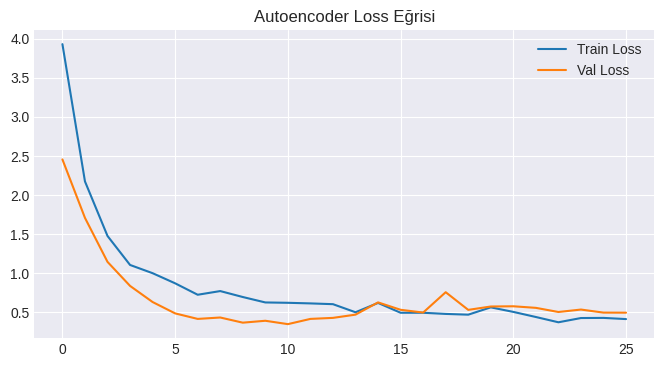

              precision    recall  f1-score   support

      Normal       0.90      0.88      0.89       416
     Anomali       0.59      0.62      0.61       113

    accuracy                           0.83       529
   macro avg       0.74      0.75      0.75       529
weighted avg       0.83      0.83      0.83       529

AUC: 0.8612


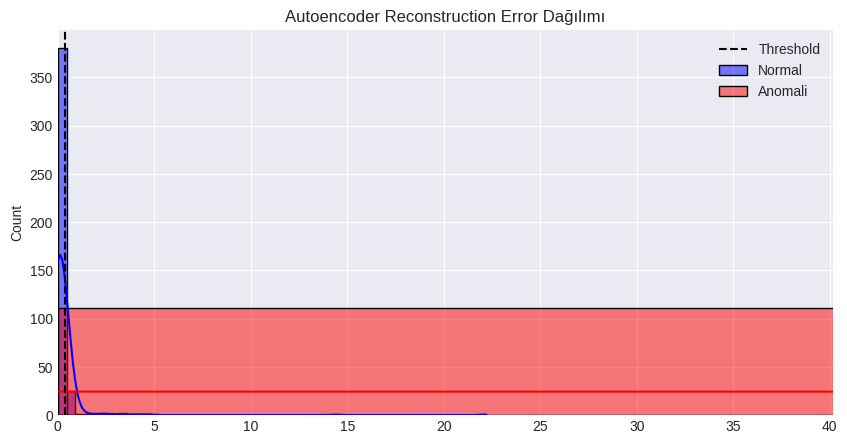

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

ae = Sequential([
    Dense(64, activation='relu', input_shape=(X_normal_train.shape[1],)),
    BatchNormalization(), Dropout(0.2),
    Dense(32, activation='relu'), BatchNormalization(),
    Dense(16, activation='relu'),
    Dense(32, activation='relu'), BatchNormalization(),
    Dense(64, activation='relu'), BatchNormalization(),
    Dense(X_normal_train.shape[1], activation='linear')
])
ae.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
X_normal_val = X_val_s[y_val.values == 0]
history = ae.fit(X_normal_train, X_normal_train, validation_data=(X_normal_val, X_normal_val),
                 epochs=150, batch_size=32, callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)], verbose=1)

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss'); plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Autoencoder Loss Eğrisi'); plt.legend(); plt.show()

recon_val = ae.predict(X_val_s, verbose=0)
scores_val = np.mean(np.power(X_val_s - recon_val, 2), axis=1)
ae_thresh, _ = find_best_threshold(scores_val, y_val.values)
recon_test = ae.predict(X_test_s, verbose=0)
scores_test = np.mean(np.power(X_test_s - recon_test, 2), axis=1)
y_pred = (scores_test > ae_thresh).astype(int)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomali']))
print(f"AUC: {roc_auc_score(y_test, scores_test):.4f}")

plt.figure(figsize=(10, 5))
sns.histplot(scores_test[y_test==0], color='blue', label='Normal', kde=True, bins=50)
sns.histplot(scores_test[y_test==1], color='red', label='Anomali', kde=True, bins=50)
plt.axvline(x=ae_thresh, color='black', linestyle='--', label='Threshold')
plt.title('Autoencoder Reconstruction Error Dağılımı')
plt.xlim([0, np.percentile(scores_test, 98)]); plt.legend(); plt.show()


---
## Bölüm 6: ROC Karşılaştırması


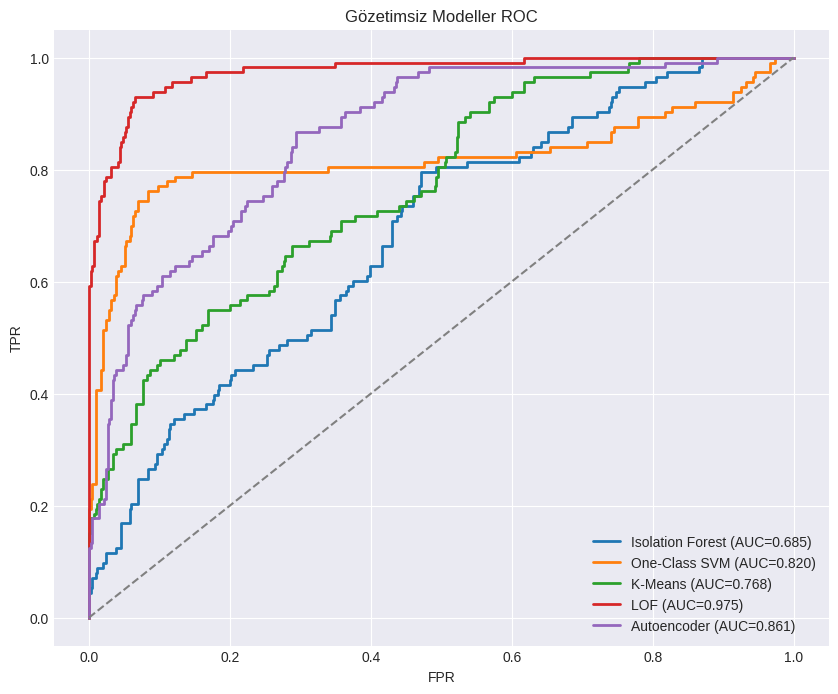

In [8]:
plt.figure(figsize=(10, 8))
all_scores = {
    'Isolation Forest': -iso.score_samples(X_test_s),
    'One-Class SVM': -ocsvm.decision_function(X_test_s),
    'K-Means': np.min(km.transform(X_test_s), axis=1),
    'LOF': -lof.score_samples(X_test_s),
    'Autoencoder': np.mean(np.power(X_test_s - ae.predict(X_test_s, verbose=0), 2), axis=1)
}
for name, sc in all_scores.items():
    fpr,tpr,_ = roc_curve(y_test, sc); ra = auc(fpr,tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={ra:.3f})')
plt.plot([0,1],[0,1],color='gray',linestyle='--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('Gözetimsiz Modeller ROC'); plt.legend(loc='lower right')
plt.show()


---
## Bölüm 7: Kaydetme ve Kanonik Model Havuzu

Bu notebook'ta Isolation Forest, One-Class SVM, K-Means, Local Outlier Factor ve
Autoencoder gösterim amacıyla ayrıntılı ele alınmıştır. Bunların yanında gözetimsiz
model havuzunun tamamı `train_all_models.py` ile eğitilir ve sonuçları NB06'da
(`final_comparison.json`) karşılaştırılır:

- sklearn ve derin: GMM, Elliptic Envelope, PCA, DBSCAN, VAE.
- PyOD ailesi: ECOD, COPOD, HBOS, CBLOF (yalnızca pyod kuruluysa eğitilir).

In [9]:
print("Kanonik gözetimsiz model havuzunun tamamı train_all_models.py'de eğitilir (bkz. NB06).")

Kanonik gözetimsiz model havuzunun tamamı train_all_models.py'de eğitilir (bkz. NB06).
